> ### Nefeli Boumpari
> 
>  Python for Analytics and AI

# Replication Notebook: Age and Gender Distortion in Online Media and Large Language Models

This notebook replicates a subset of the analyses presented in the paper
**"Age and gender distortion in online media and large language models"**
published in *Nature* (Vol. 646, October 2025) by
**Douglas Guilbeault, Solène Delecourt and Bhargav Srinivasa Desikan**.
The paper provides large-scale evidence that age-related gender bias pervades
online media, showing that women are consistently represented as younger than
men across nearly 1.4 million images and videos from platforms such as Google,
Wikipedia, IMDb, Flickr and YouTube, as well as in nine large language models
trained on billions of words from the internet. Beyond documenting this
distortion, the authors demonstrate that mainstream algorithms actively amplify
it. The focal point of this replication is the paper's pre-registered
human experiment, in which a nationally representative sample of 459 US
participants was randomised into either an image condition, where they used
Google Images to search for and upload photographs of occupations before
estimating the average age of someone in that occupation, or a control
condition, where they estimated the same ages without any prior exposure to
occupational images. By replicating the construction of the key experimental
variables, the main statistical tests and the central visualisations of the
paper, this notebook aims to reproduce and contextualise the core finding that
uploading a female image of an occupation leads participants to estimate that
occupation as significantly younger than the control baseline, while uploading
a male image leads to significantly older estimates, resulting in a gap of
approximately 5.46 years between the two conditions. Additionally, this
notebook extends the original analysis by running ANOVA models and regression
analyses with occupation and participant fixed effects to further investigate
the amplification of age-related gender bias through Google Image search,
and by reproducing the paper's visualisation of age and gender associations
in the GPT-2 Large language model.

### Environment Setup

In [270]:
# standard library
import warnings
warnings.filterwarnings("ignore")

# data manipulation and numerical funcitons
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import altair as alt
from plotnine import *
%matplotlib inline

# statistics
import pingouin as pg
import scipy.stats
from scipy.stats import (ttest_ind, ttest_1samp,ttest_rel, t as t_dist)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from patsy.contrasts import Sum

In [271]:
#-- Fetch data
url1 = "https://drive.google.com/uc?export=download&id=1-_PYdwqtdTRhZfTBMxCowRhFjFz9aJR_"
df1 = pd.read_csv(url1) # GPT2-large-dimensions.csv

url2 = "https://drive.google.com/uc?export=download&id=10TKm_MYZdfIteWWKw4t33XZ1vUAVSJwM"
df2 = pd.read_csv(url2) # experiment_control.csv

url3 = "https://drive.google.com/uc?export=download&id=10WIozMmOFErIu0Fu_uiVq5RgpvkCFzwQ"
df3 = pd.read_csv(url3) # experiment_treatment.csv

In [272]:
#-- Rename the main scores to fit the blueprint analysis names
df1.rename(columns={"Social.Category" : "social_category",
                    "gender.main" : "gender_score",
                    "gender_norm.main" : "gender_norm_main",
                    "gender.ext" : "gender_ext",
                    "gender_norm.ext" : "gender_norm_ext",
                    "gender.red" : "gender_red",
                    "gender_norm.red" : "gender_norm_red",
                    "age.main" : "age_score",
                    "age_norm.main" : "age_norm_main",
                    "age.ext" : "age_ext",
                    "age_norm.ext" : "age_norm_ext",
                    "age.red" : "age_red",
                    "age_norm.red" : "age_norm_red"
                    }, inplace = True)

### Correlation between age and gender

In [273]:
#-- Use the Pearson's correlation metric for raw association scores for gender and age
pg.corr(df1["gender_score"], df1["age_score"])

,n,r,CI95,p_val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0,inf,1.0


The columns of the output are the following:
- (n) Number of observations/records
- (r) Pearson's rho (estimated correlation)
- (CI95) 95% Confidence interval for the pearson's rho
- (p-val) P-value for the hypothesis test
- (BF10) Bayes' Factor: strength of evidence ration (How likely the data are if the alternative hypothesis is true, compared to Ho)
- (power): the power of the test

Note: The hypothesis test that is being performed with this command is the following :
- **H₀:** ρ = 0 (correlation is NOT statistically significant)
- **H₁:** ρ ≠ 0 (correlation is statistically significant)

We can see that from 3495 observations in our availability, the pearson's correlation between the variables of gender and age is estimated at approximately 0.87; meaning that there is a strong positive linear correlation between these two variables. The 100(1-a)% confidence interval for pearson's rho, suggests that with 95% confidence, the pearson's rho takes values between 0.86 and 0.88 (95 out of 100 times). Since the confidence interval does not include the value of 0, we can say that with a=5%, we reject the null hypothesis, which means that the correlation between gender and age is actually statistically significant. We can confirm this by looking at the p-value, which is equal to 0 (< 0.05) consequently leading to the rejection of Ho. As for the Bayes' Factor, a large BF10 is evidence to reject the null hypothesis. As a rule of thumb, if it takes values bigger than 100, the evidence is decisive. Since the BF10 takes a value that is huge (inf) we can confidently say that the null hypothesis is rejected. 

## Correlation Between Age and Gender Score Variants

The dataset contains three versions of both the gender and age association scores,
each derived from a different subset of the word embedding model. Specifically:

- `age_score` / `gender_score`; the **main** scores, derived from the primary
  embedding model (GPT-2 Large), used as the central measures throughout the paper
- `age_ext` / `gender_ext`; scores derived from an **extended** set of seed words
  used to define the age and gender dimensions in the embedding space
- `age_red` / `gender_red`; scores derived from a **reduced** set of seed words

Before proceeding to the main regression analysis, we examine the correlations
between these three versions separately for age and gender. This serves as a
robustness check: if the three variants are highly correlated with each other,
it confirms that the association scores are stable and not sensitive to the
specific choice of seed words used to define the demographic dimensions. This
is relevant to the paper's claim that results are robust to alternative methods
for extracting age and gender associations, which is reported in Supplementary
Figure 13 of the original study.

The two heatmaps below show the pairwise Pearson correlations between the three
age score variants and the three gender score variants respectively.

In [274]:
#-- Save the quantitative variables of interest in a separate object
quantitative_predictors_hm1 = df1.loc[:, ["age_red", "age_ext", "age_score"]]
quantitative_predictors_hm2 = df1.loc[:, ["gender_red", "gender_ext", "gender_score"]]

In [275]:
#-- Compute correlations
corr1 = quantitative_predictors_hm1.corr()
corr2 = quantitative_predictors_hm2.corr()

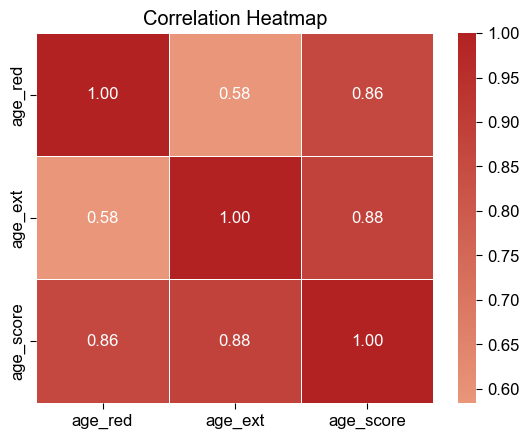

In [276]:
#-- Generate a sequential colormap 
cmap = LinearSegmentedColormap.from_list(
    "darksalmon_to_firebrick", 
    ["darksalmon", "firebrick"])
#-- Draw the heatmaps
sns.heatmap(corr1, cmap=cmap, annot=True, fmt=".2f", linewidths=0.5, linecolor="white")
plt.title("Correlation Heatmap")
plt.show()

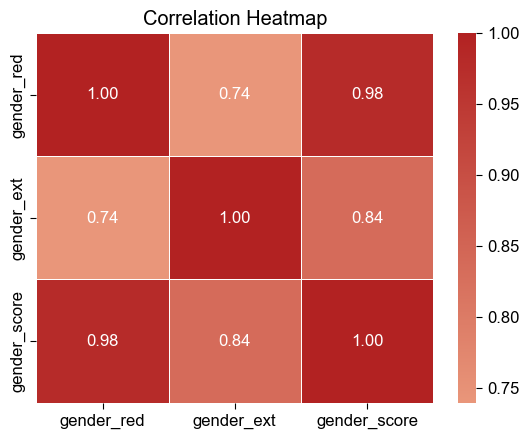

In [277]:
sns.heatmap(corr2, cmap=cmap, annot=True, fmt=".2f", 
            linewidths=0.5, linecolor="white")
plt.title("Correlation Heatmap")
plt.show()

# Relationship between Age and Gender

## Normalized Age and Gender Variables

Before fitting the linear regression model, we would like to mention a methodology that was applied to the variables of interest. The variables **age_norm_main** and **gender_norm_main** were constructed to represent the age and gender associations of each category. These variables were derived from cosine-distance scores computed between category embeddings and demographic reference word clusters.

### Gender Association

For each category, cosine distances were computed with respect to two reference clusters representing **female-associated** and **male-associated** terms. These distances capture the relative semantic proximity of each category to gendered word groups in the embedding space.

To ensure comparability across categories and to constrain the variable to a consistent scale, the resulting scores were **normalized using min-max normalization**:

$$
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

This transformation rescales the values to the interval **[0,1]**, where:

- values closer to **0** indicate stronger association with **female-related terms**
- values closer to **1** indicate stronger association with **male-related terms**

The resulting normalized variable is stored as **`gender_norm_main`**.

### Age Association

An analogous procedure was applied to compute **age-related associations**. Cosine distances were calculated between category embeddings and reference clusters representing **younger** and **older** age groups.

These scores were again normalized using min–max scaling:

$$
x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

After normalization:

- values closer to **0** indicate stronger association with **younger-related terms**
- values closer to **1** indicate stronger association with **older-related terms**

The normalized variable is stored as **`age_norm_main`**.

### Use in the Regression Model

Both normalized variables are included as **continuous predictors** in the linear regression model. Because they are scaled to the same range \([0,1]\), the regression coefficients can be interpreted as the effect of moving from the **minimum to the maximum association** along each demographic dimension.

In [278]:
print(df1['age_norm_main'].min(), df1['age_norm_main'].max())
print(df1['gender_norm_main'].min(), df1['gender_norm_main'].max())

0.0 1.0
0.0 1.0


Run a regression between the normalized age and gender measures.

In [279]:
mod0 = smf.ols(formula = "age_norm_main ~ gender_norm_main", data = df1)
mod0_res = mod0.fit()
mod0_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          age_norm_main   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                 1.114e+04
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:35:13   Log-Likelihood:                 5425.6
No. Observations:                3495   AIC:                        -1.085e+04
Df Residuals:                    3493   BIC:                        -1.083e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0211      0.003     -6.510      0.000      -0.027      -0.015
gender_norm_main     0.7450      0.007    105.565      0.000       0.731       0.759
==============================================================================
Omnibus:                      829.901   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4643.267
Skew:                           1.012   Prob(JB):                         0.00
Kurtosis:                       8.271   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Linear Regression Model

The estimated linear regression model is:

$$
\text{age\_norm\_main}_i = -0.0211 + 0.745\,\text{gender\_norm\_main}_i + \varepsilon_i
$$

where:

- $\text{age\_norm\_main}_i$ is the normalized age association for observation $i$
- $\text{gender\_norm\_main}_i$ is the normalized gender association
- $-0.0211$ is the intercept
- $0.745$ is the estimated coefficient for gender association
- $\varepsilon_i$ is the error term

### Regression Plot 

Define the special points that will be highlighted in the scatter plot later.

In [280]:
bluepoints = df1[df1["social_category"].isin(["military personnel",
                                            "elected official",
                                            "chairman of the board",
                                            "director of research",
                                            "chief of staff"])]


orangepoints = df1[df1["social_category"].isin(["intern",
                                              "homoeopath",
                                              "novice", 
                                              "secretary",
                                              "cook"])] 

Print the coordinates of these points (this will help us manually set the label positions in the plot later on)

In [281]:
print(bluepoints[["social_category", "gender_norm_main", "age_norm_main"]])
print(orangepoints[["social_category", "gender_norm_main", "age_norm_main"]])

            social_category  gender_norm_main  age_norm_main
533   chairman of the board          0.963212       0.670336
577          chief of staff          0.835858       0.551170
1034   director of research          1.000000       0.650883
1154       elected official          0.862913       0.643438
2360     military personnel          0.800198       0.658630
     social_category  gender_norm_main  age_norm_main
816             cook          0.165446       0.072551
1809      homoeopath          0.136193       0.116632
1931          intern          0.014183       0.056865
2551          novice          0.313752       0.116941
3071       secretary          0.306086       0.096243


In [282]:
#-- Set label positions
bluepoints = bluepoints.copy()
orangepoints = orangepoints.copy()

#-- General Rules:
# increase x_label -->  line goes right
# decrease x_label --> line goes left
# increase y_label --> line goes up
# decrease y_label --> line goes down

# Order: chairman, chief, director, elected, military
bluepoints["x_label"] = [0.95, 0.90, 1.10, 0.60, 0.40]
bluepoints["y_label"] = [0.95, 0.42, 0.55, 0.82, 0.72]

# Order: cook, homoeopath, intern, novice, secretary
orangepoints["x_label"] = [0.10, -0.15, -0.20, 0.55, 0.25]
orangepoints["y_label"] = [-0.05, 0.18, 0.08, 0.00, -0.05]

#-- Shorten segment to 90% of the way to the label
for pts in [bluepoints, orangepoints]:
    pts["x_label_seg"] = pts["gender_norm_main"] + 0.9 * (pts["x_label"] - pts["gender_norm_main"])
    pts["y_label_seg"] = pts["age_norm_main"] + 0.9 * (pts["y_label"] - pts["age_norm_main"])

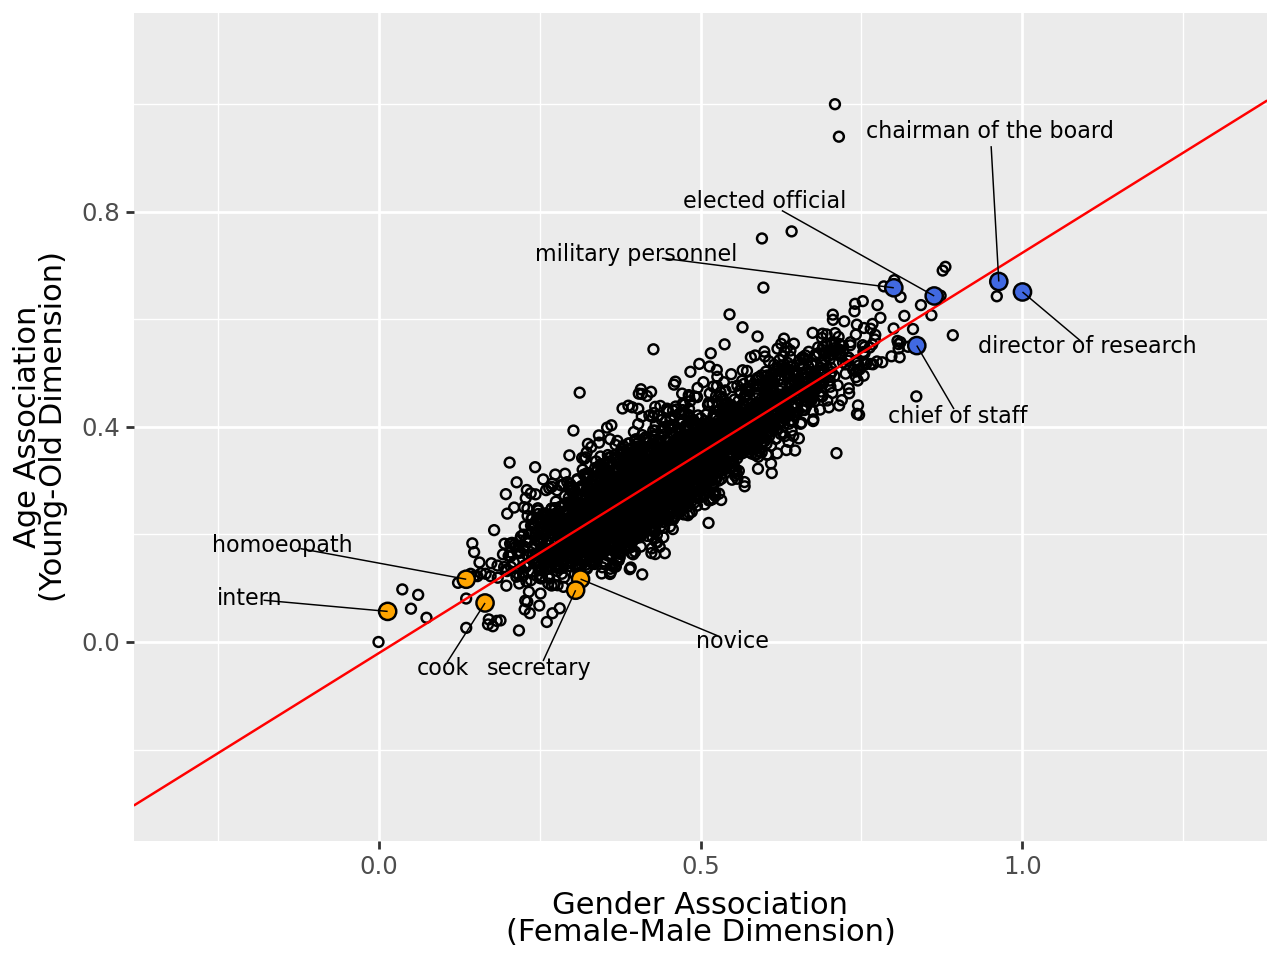

In [283]:
#-- Create regression plot
intercept = mod0_res.params[0]
slope = mod0_res.params[1]

(ggplot(df1, aes(x = "gender_norm_main", y = "age_norm_main"))+ 
         geom_point(shape = "o", fill = "none", color = "black")+
         geom_abline(intercept = intercept, slope = slope, color = "red")+
         geom_point(bluepoints, color = "black", fill = "royalblue", size = 3)+
         geom_point(orangepoints, color = "black", fill = "orange", size = 3)+
         geom_segment(aes(x = "gender_norm_main", y = "age_norm_main", xend = "x_label_seg", yend = "y_label_seg"),
                data = bluepoints, color = "black", size = 0.3)+
         geom_segment(aes(x = "gender_norm_main", y = "age_norm_main", xend = "x_label_seg", yend = "y_label_seg"),
                data = orangepoints, color = "black", size = 0.3)+
         geom_text(aes(x = "x_label", y = "y_label", label = "social_category"),
             data = bluepoints, size = 8, ha = "center")+
         geom_text(aes(x = "x_label", y = "y_label", label = "social_category"),
             data = orangepoints, size = 8, ha = "center")+
         xlim(-0.3, 1.3)+
         ylim(-0.3, 1.1)+
         labs(x = "Gender Association\n(Female-Male Dimension)",
              y = "Age Association\n(Young-Old Dimension)"))

### Why are the other outliers not highlighted by the authors?

> The orange highlighted categories illustrate some of the categories that have the  youngest and most female associations, whereas the blue highlighted categories illustrate some of the categories that have the oldest and most male associations. The highlighted points are not selected purely on statistical grounds as the most extreme values in the distribution. Instead they are chosen to illustrate a theoretically meaningful contrast. The orange categories (intern, homoeopath, novice, secretary, cook) represent roles that are simultaneously the most female-associated and the most youth-associated in the embedding space, while the blue categories (chairman of the board, military personnel, elected official, chief of staff, director of research) represent roles that are simultaneously the most male-associated and the most age-associated. Together they anchor the two ends of the diagonal trend line, making the correlation between gender and age associations visually intuitive and conceptually concrete. There are also likely other data points that sit at similarly extreme positions on the axes, but labelling all of them would clutter the figure and dilute the message. By picking recognizable, socially meaningful occupations,  the reader can, let's say,  instantly understand why a chairman of the board would be stereotypically associated with older men, and why an intern would be associated with younger women, in a way that a purely statistical outlier might not convey.


### Make Regression Plot Interactive (via Altair library)

In [284]:
# state the special colored points
bluepoints = df1[df1["social_category"].isin(["military personnel", "elected official", "chairman of the board",
                                                 "director of research", "chief of staff"])].copy()
orangepoints = df1[df1["social_category"].isin(["intern", "homoeopath", "novice", "secretary", "cook"])].copy()

# for the regression line take parameters needed
intercept = mod0_res.params[0]
slope = mod0_res.params[1]
x_range = pd.DataFrame({"gender_norm_main": [0, 1.05]})
x_range["age_norm_main"] = intercept + slope * x_range["gender_norm_main"]

# shared tooltip
tooltip = [
    alt.Tooltip("social_category:N", title="social_category"),
    alt.Tooltip("gender_norm_main:Q", title="gender_norm", format=".3f"),
    alt.Tooltip("age_norm_main:Q", title="age_norm",    format=".3f")]

# shared axis encodings
x_enc = alt.X("gender_norm_main:Q",
               scale=alt.Scale(domain=[0, 1.05]),
               title=["Gender Association", "(Female-Male Dimension)"],
               axis=alt.Axis(tickCount=6))

y_enc = alt.Y("age_norm_main:Q",
               scale=alt.Scale(domain=[0, 1.05]),
               title=["Age Association", "(Young-Old Dimension)"],
               axis=alt.Axis(tickCount=6))

# base scatter (grey points)
scatter = (alt.Chart(df1)
           .mark_point(filled=True, color="lightgrey", stroke="grey",
                       strokeWidth=0.5, size=40, opacity=0.6)
           .encode(x=x_enc, y=y_enc, tooltip=tooltip))

# regression line
reg_line = (alt.Chart(x_range)
            .mark_line(color="red", strokeWidth=2)
            .encode(x="gender_norm_main:Q", y="age_norm_main:Q"))

# blue special points
blue_scatter = (alt.Chart(bluepoints)
                .mark_point(filled=True, color="dodgerblue", stroke="grey",
                            strokeWidth=0.5, size=60, opacity=0.9)
                .encode(x="gender_norm_main:Q", y="age_norm_main:Q", tooltip=tooltip))

# orange special points
orange_scatter = (alt.Chart(orangepoints)
                  .mark_point(filled=True, color="orange", stroke="grey",
                              strokeWidth=0.5, size=60, opacity=0.9)
                  .encode(x="gender_norm_main:Q", y="age_norm_main:Q", tooltip=tooltip))

# combine all layers
chart = (scatter + reg_line + blue_scatter + orange_scatter).properties(
    width=500,
    height=450
).configure_axis(
    grid=True,
    gridColor="lightgrey",
    gridWidth=0.5,
    domainColor="lightgrey",
    tickColor="lightgrey",
    titleColor="black"
).configure_view(strokeWidth=0)

chart

alt.LayerChart(...)

# Amplification via Google Search

### The experiment

To test whether online images cause people to form biased age beliefs, the authors ran a pre-registered, nationally representative experiment (n = 459) with two conditions:
- **Image condition (treatment)**: Participants used Google Images to search for and upload a photograph of a given occupation. They then estimated the average age of someone in that occupation and labelled the gender of the person in the image they uploaded.
- **Control condition**: Participants searched for images of unrelated, non-gendered categories (e.g. apple, guitar) and then estimated the average age of someone in a randomly assigned occupation, without having seen any occupational image first.

This design allows us to measure whether seeing a male or female occupational image shifts a participant's age estimate relative to the unbiased control baseline.

The following figure visualises the core experimental result: the distribution of age estimates in the treatment condition, broken down by the gender of the image uploaded, and centered relative to the control group average. 

In [285]:
control = df2.copy()
treatment = df3.copy()

### Step 1: Aggregate age estimates by category
>We first summarise the raw data by computing average age estimates per occupation.
For the **control group**, we calculate the mean `age` and mean `ideal_age` for each
occupation category. These will serve as our baseline reference values (`c_age` and
`c_ideal`). For the **treatment group**, we calculate the mean `age` per occupation
*and* per gender of image uploaded, since the gender of the image is the key
experimental variable of interest.

In [286]:
control_agg = (control.groupby("category").agg(c_age=("age", "mean"), c_ideal=("ideal_age", "mean")).reset_index())

treatment_agg = (treatment.groupby(["category", "gender"]).agg(age=("age", "mean")).reset_index())

### Step 2: Merge Treatment and Control, filter ambiguous responses
>We merge the aggregated treatment data with the control averages on `category`,
so that each treatment row now also contains the control baseline (`c_age`, `c_ideal`)
for the same occupation. We then drop rows where the participant labelled the uploaded
image as `"Not Sure"`, since these cannot be assigned to either the Female or Male
condition and would introduce noise into the gender comparison.

In [287]:
treatment_agg_full = treatment_agg.merge(control_agg, on="category")
treatment_agg_full_main = treatment_agg_full[treatment_agg_full["gender"] != "Not Sure"].copy()

### Step 3: Compute centered age estimates (aggregated)
> We create the key outcome variable: **age centered relative to control** (`age_cent`).
This is simply the treatment group's mean age estimate for an occupation minus the
control group's mean age estimate for the same occupation. A value of 0 means the
treatment participant estimated the same age as the control average; negative values
mean they estimated younger; positive values mean older. This centering removes
occupation-level differences in absolute age (e.g. a surgeon is generally estimated
older than an intern regardless of condition), isolating the effect of seeing a
gendered image.

In [288]:
treatment_agg_full_main["age_cent"] = treatment_agg_full_main["age"] - treatment_agg_full_main["c_age"]
treatment_agg_full_main["age_ideal_cent"] = treatment_agg_full_main["age"] - treatment_agg_full_main["c_age"]

### Step 4: Repeat at the individual level
> Rather than working with occupation-level averages, we now repeat the merge and
centering at the **individual response level**. This is the dataset used for the
main plot and t-tests. Each row represents a single participant's age estimate for
a single occupation, paired with the control baseline for that occupation.


In [289]:
treatment_full = treatment.merge(control_agg, on="category")
treatment_full_main = treatment_full[treatment_full["gender"] != "Not Sure"].copy()

treatment_full_main["age_cent"] = treatment_full_main["age"] - treatment_full_main["c_age"]
treatment_full_main["age_ideal_cent"] = treatment_full_main["age"] - treatment_full_main["c_ideal"]

> We also create a numeric version of the gender variable (`gender_num`) for use in
regression models later: Female = −1, Male = 1, Not Sure = 0. Finally, we combine
the treatment and control data into a single dataset (`dt_main`) for any analyses
that require both conditions together.

In [290]:
# gender_num coding: Female=-1, Male=1, Not Sure=0
gender_map = {"Female": -1, "Male": 1, "Not Sure": 0}
control["gender_num"] = control["gender"].map(gender_map)
treatment["gender_num"] = treatment["gender"].map(gender_map)

dt_main = pd.concat([treatment, control], ignore_index=True)

### Step 5: Prepare data for figure
> We extract the centered age estimates (`age_cent`) separately for participants who
uploaded a Female image and those who uploaded a Male image, dropping any missing
values. Then we create a raw data frame that will hold those values and get the means.

In [291]:
female_vals = treatment_full_main[treatment_full_main["gender"] == "Female"]["age_cent"].dropna()
male_vals   = treatment_full_main[treatment_full_main["gender"] == "Male"]["age_cent"].dropna()

# create raw data dataframe
df_raw = pd.DataFrame({
    "x": pd.concat([female_vals, male_vals]).reset_index(drop=True),
    "group": ["female"] * len(female_vals) + ["male"] * len(male_vals)
})

# get means for vlines
female_mean = female_vals.mean()
male_mean = male_vals.mean()

### Step 6: Construct the plot 

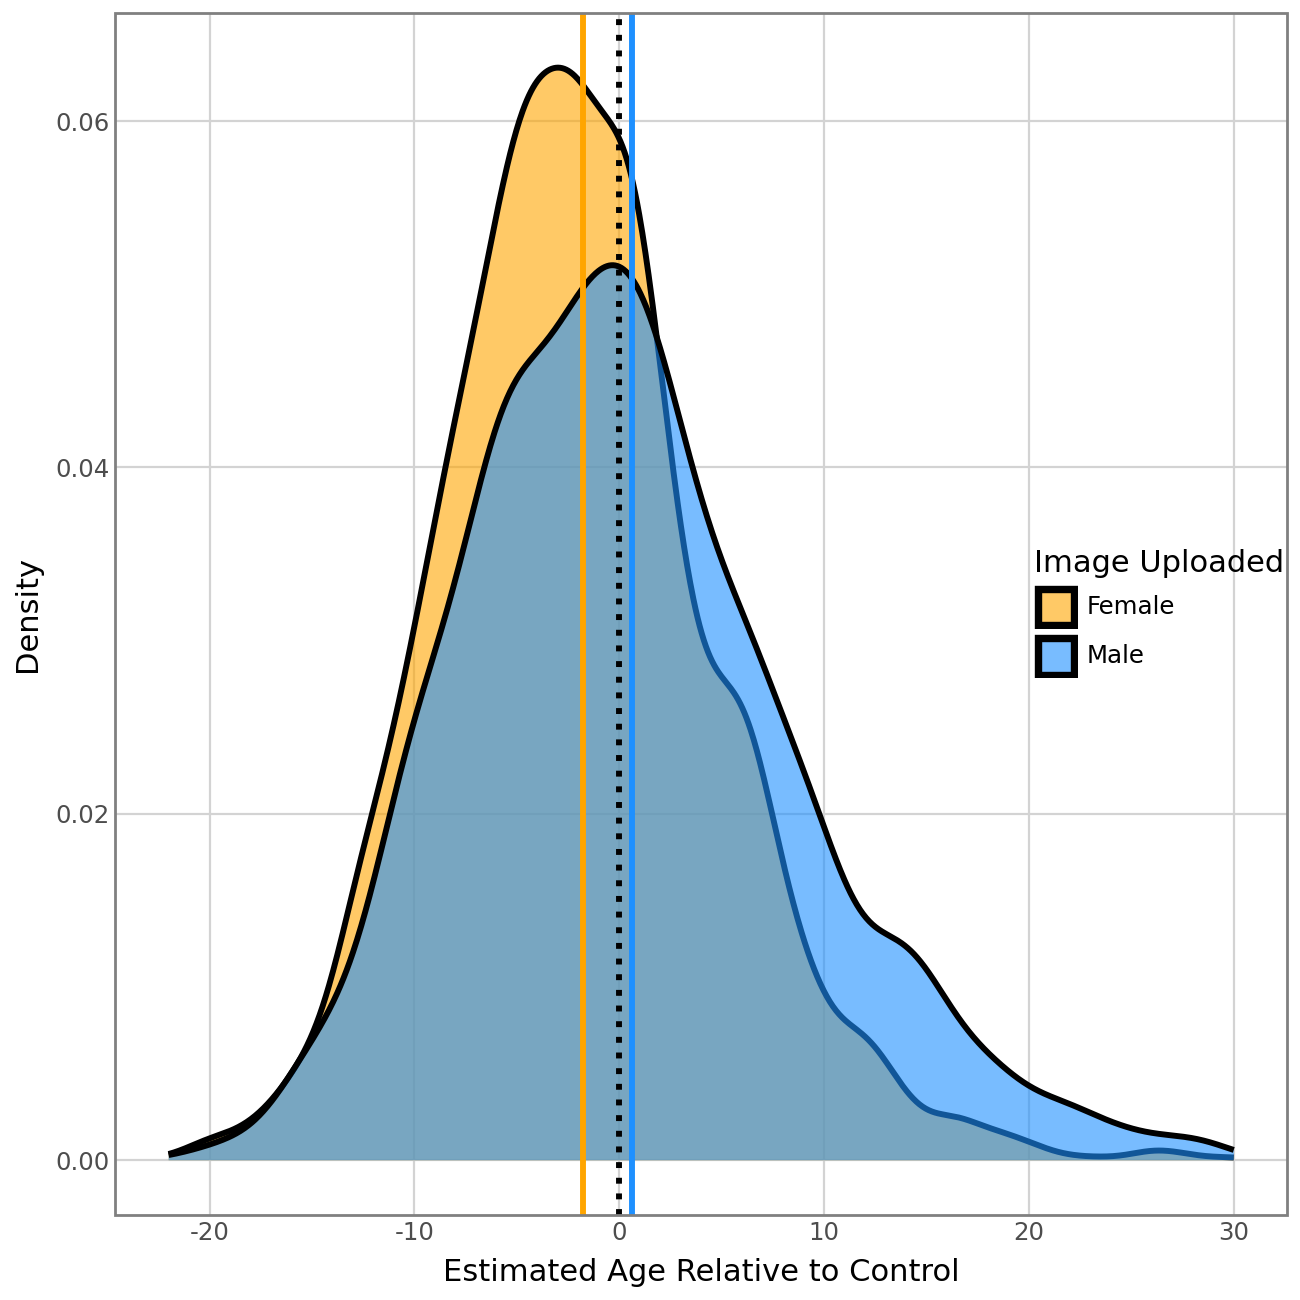

In [292]:
(ggplot(df_raw, aes(x='x', fill='group'))+
     geom_density(alpha=0.6, size=1.2)+
     geom_vline(xintercept=0, linetype='dotted', size=1.2)+
     geom_vline(xintercept=female_mean, color='orange', size=1.2)+
     geom_vline(xintercept=male_mean, color='dodgerblue', size=1.2)+
     scale_fill_manual(
         values={"female": "orange", "male": "dodgerblue"},
         labels={"female": "Female", "male": "Male"})+
     guides(fill=guide_legend(override_aes={"fill": ["orange", "dodgerblue"], "color": "black", "size": 1.5}))+
     labs(x="Estimated Age Relative to Control",
          y="Density",
          fill="Image Uploaded")+
     xlim(-22, 30)+
     theme_minimal()+
     theme(panel_grid_major=element_line(color="lightgrey", size=0.8),
           panel_grid_minor=element_blank(),
           panel_border=element_rect(color="grey", fill=None, size=1),
           legend_position=(1, 0.5),
           legend_background=element_blank(),
           figure_size=(6.5, 6.5)))

### Statistical Tests

We now verify the three main claims from the paper using t-tests:

1. **Female vs. Male condition:** Participants who uploaded a female image estimated
   occupations as 5.46 years younger than those who uploaded a male image.
2. **Female vs. Control:** Uploading a female image led to estimates 1.75 years
   *lower* than the control baseline (meaning `age_cent` is significantly negative).
3. **Male vs. Control:** Uploading a male image led to estimates 0.64 years
   *higher* than the control baseline (meaning `age_cent` is significantly positive).

Tests 2 and 3 are **one-sample t-tests against zero**. Since `age_cent` is already
centered on the control mean, testing whether it differs from 0 is equivalent to
testing whether the treatment differs from control.

In [293]:
# 1. Female vs Male - raw age, simple two-sample t-test
female_age = treatment_full_main[treatment_full_main["gender"] == "Female"]["age"].dropna()
male_age = treatment_full_main[treatment_full_main["gender"] == "Male"]["age"].dropna()


t1 = ttest_ind(female_age, male_age)
print(f"Female vs Male (raw age): mean diff = {female_age.mean() - male_age.mean():.2f} years")
print(f"  t = {t1.statistic:.2f}, p = {t1.pvalue:.2e}\n")

Female vs Male (raw age): mean diff = -5.46 years
  t = -19.26, p = 1.15e-79



In [294]:
# 2. Female vs Control (one-sample, H0: mean = 0)
t2 = ttest_1samp(female_vals, 0)
print(f"Female vs Control: mean = {female_vals.mean():.2f} years relative to control")
print(f"  t = {t2.statistic:.2f}, p = {t2.pvalue:.2e}\n")

Female vs Control: mean = -1.75 years relative to control
  t = -11.32, p = 4.82e-29



In [295]:
# 3. Male vs Control (one-sample, H0: mean = 0)
t3 = ttest_1samp(male_vals, 0)
print(f"Male vs Control: mean = {male_vals.mean():.2f} years relative to control")
print(f"  t = {t3.statistic:.2f}, p = {t3.pvalue:.2e}")

Male vs Control: mean = 0.64 years relative to control
  t = 3.42, p = 6.37e-04


# Investigate the Amplification

To more rigorously test whether exposure to occupational images *amplifies* 
age-related gender bias beyond people's pre-existing beliefs, we run a linear 
regression on the **combined treatment and control dataset** (`dt_main`).

The model predicts raw age estimates using:
- **`condition × gender` interaction term** -  the key term of interest. It tests whether 
  the effect of gender on age estimates is *larger* in the image condition than in 
  the control condition, i.e. whether Google Images amplifies the gender-age bias 
  that already exists in people's baseline beliefs.
- **`category` fixed effects** - controls for the fact that some occupations are 
  simply estimated as older than others regardless of condition.
- **`subj` fixed effects** - controls for individual participants who may 
  systematically estimate ages higher or lower overall.

If the interaction term is significant and positive, it means that seeing a male 
(vs female) image *further increases* the gender gap in age estimates, above and 
beyond the gap that already exists in the control condition.

> `dt_model` is the combined treatment and control dataset filtered to include only
rows where the gender variable takes the value "Female" or "Male". Rows where the
participant labelled the uploaded image as "Not Sure" are excluded because they
cannot be meaningfully assigned to either the female or male image condition, and
including them would introduce ambiguity into the regression model where gender
is used as a predictor. This filtered dataset is the one used for all subsequent
regression and ANOVA analyses.

In [296]:
# Use only Female and Male (drop Not Sure) from the combined dataset
dt_model = dt_main[dt_main["gender"].isin(["Female", "Male"])].copy()
dt_model

,subj,category,age,gender,condition,gender_num,ideal_age
0,55a55bd7fdf99b790558627c,artstudent,18.63,Female,Image,-1,NaN
1,55a55bd7fdf99b790558627c,astronaut,30.29,Female,Image,-1,NaN
2,55a55bd7fdf99b790558627c,automotiveengineer,36.06,Male,Image,1,NaN
3,55a55bd7fdf99b790558627c,chiefexecutiveofficer,46.11,Female,Image,-1,NaN
4,55a55bd7fdf99b790558627c,computerexpert,30.70,Female,Image,-1,NaN
...,...,...,...,...,...,...,...
10091,654918baca0c382f1b8d2dff,trainednurse,35.12,Female,Control,-1,33.38
10092,6559147a65618b0217721344,trainednurse,29.76,Female,Control,-1,29.36
10093,655bb55ae732f18ce1953efe,trainednurse,38.07,Female,Control,-1,44.77
10094,657228e3073464323075c94b,trainednurse,25.47,Female,Control,-1,29.09


In [297]:
# run regression 
mod1 = smf.ols(
    formula = 'age ~ C(condition, Treatment(reference="Control"))*C(gender, Treatment(reference="Male")) + C(category) + C(subj)',
    data=dt_model)
mod1_res = mod1.fit()
mod1_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     22.30
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:35:31   Log-Likelihood:                -28066.
No. Observations:                8514   AIC:                         5.715e+04
Df Residuals:                    8005   BIC:                         6.074e+04
Df Model:                         508                                         
Covariance Type:            nonrobust                                         
==========================================================================================================================================================================
                                                                                                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                 44.1459      1.524     28.963      0.000      41.158      47.134
C(condition, Treatment(reference="Control"))[T.Image]                                                     -4.7819      1.447     -3.305      0.001      -7.618      -1.946
C(gender, Treatment(reference="Male"))[T.Female]                                                          -2.1919      0.288     -7.614      0.000      -2.756      -1.628
C(category)[T.appliedscientist]                                                                           -0.1997      0.772     -0.259      0.796      -1.713       1.314
C(category)[T.artstudent]                                                                                -15.9195      0.769    -20.691      0.000     -17.428     -14.411
C(category)[T.artteacher]                                                                                 -1.5589      0.760     -2.050      0.040      -3.049      -0.068
C(category)[T.astronaut]                                                                                   0.8480      0.756      1.121      0.262      -0.635       2.331
C(category)[T.astrophysicist]                                                                              5.5395      0.746      7.422      0.000       4.076       7.002
C(category)[T.automotiveengineer]                                                                         -3.0039      0.741     -4.056      0.000      -4.456      -1.552
C(category)[T.bookkeeper]                                                                                 -0.1153      0.754     -0.153      0.878      -1.593       1.362
C(category)[T.cardiologist]                                                                                7.2159      0.752      9.600      0.000       5.743       8.689
C(category)[T.chiefexecutiveofficer]                                                                      10.7181      0.744     14.401      0.000       9.259      12.177
C(category)[T.chiropractor]                                                                                0.8699      0.749      1.161      0.246      -0.599       2.338
C(category)[T.clarinetist]                                                                                -3.6484      0.738     -4.943      0.000      -5.095      -2.202
C(category)[T.climatologist]                                                                               1.0234      0.759      1.348      0.178      -0.465       2.511
C(cat

- Now we will do another regression for age using only `category` and `subj` as the
independent  variables. We will the use that model to predict the age
for the combined  treatment and control dataset.

- Prepare the data first. Keep only the known genders and discard the ambiguous ones.

In [298]:
dt_full = dt_main[dt_main["gender"].isin(["Female", "Male"])].copy()

In [299]:
# Fit baseline on the FULL combined dataset (not just Female/Male treatment rows)
mod2 = smf.ols("age ~ C(category) + C(subj)", data=dt_full)
mod2_res = mod2.fit()
mod2_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.576
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     21.53
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:35:33   Log-Likelihood:                -28162.
No. Observations:                8514   AIC:                         5.734e+04
Df Residuals:                    8007   BIC:                         6.091e+04
Df Model:                         506                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               44.2252      1.539     28.736      0.000      41.208      47.242
C(category)[T.appliedscientist]         -1.5052      0.775     -1.943      0.052      -3.024       0.013
C(category)[T.artstudent]              -17.2907      0.768    -22.512      0.000     -18.796     -15.785
C(category)[T.artteacher]               -3.7093      0.749     -4.950      0.000      -5.178      -2.240
C(category)[T.astronaut]                 0.6670      0.765      0.872      0.383      -0.832       2.166
C(category)[T.astrophysicist]            5.3222      0.755      7.053      0.000       3.843       6.801
C(category)[T.automotiveengineer]       -2.7564      0.749     -3.681      0.000      -4.224      -1.289
C(category)[T.bookkeeper]               -1.9309      0.746     -2.588      0.010      -3.393      -0.468
C(category)[T.cardiologist]              6.8756      0.760      9.050      0.000       5.386       8.365
C(category)[T.chiefexecutiveofficer]    10.1332      0.751     13.488      0.000       8.660      11.606
C(category)[T.chiropractor]              0.5772      0.757      0.762      0.446      -0.907       2.062
C(category)[T.clarinetist]              -4.4974      0.740     -6.075      0.000      -5.949      -3.046
C(category)[T.climatologist]             0.5311      0.766      0.693      0.488      -0.971       2.034
C(category)[T.computerexpert]           -5.6404      0.746     -7.561      0.000      -7.103      -4.178
C(category)[T.cosmeticsurgeon]           4.3045      0.760      5.665      0.000       2.815       5.794
C(category)[T.dietician]                -4.6026      0.744     -6.187      0.000      -6.061      -3.144
C(category)[T.dressmaker]               -1.2897      0.726     -1.776      0.076      -2.713       0.134
C(category)[T.editorinchief]             6.8869      0.764      9.012      0.000       5.389       8.385
C(category)[T.educator]                 -3.7278      0.774     -4.819      0.000      -5.244      -2.211
C(category)[T.englishprofessor]          7.2836      0.778      9.365      0.000       5.759       8.808
C(category)[T.englishteacher]           -3.3781      0.734     -4.601      0.000      -4.817      -1.939
C(category)[T.fashiondesigner]          -5.7644      0.743     -7.754      0.000      -7.222      -4.307
C(category)[T.fashionmodel]            -14.9981      0.759    -19.768      0.000     -16.485     -13.511
C(category)[T.financialanalyst]         -0.8069      0.746     -1.081      0.280      -2.270       0.656
C(category)[T.geneticist]                0.9448      0.788      1.199      0.231      -0.600       2.490
C(category)[T.graphicdesigner]          -8.7966      0.775    -11.355      0.000     -10.315      -7.278
C(category)[T.harpist]                

- Add predictions and residuals

In [300]:
dt_full["predicted"] = mod2_res.predict(dt_full)
dt_full["residuals"] = dt_full["age"] - dt_full["predicted"]

> We can inspect the combined dataset to confirm that the predicted values and
residuals have been correctly added as new columns. Each row represents a single
participant's age estimate for a single occupation, and now also contains the
baseline model's prediction for that row and the corresponding residual.

In [301]:
dt_full

,subj,category,age,gender,condition,gender_num,ideal_age,predicted,residuals
0,55a55bd7fdf99b790558627c,artstudent,18.63,Female,Image,-1,NaN,21.061530,-2.431530
1,55a55bd7fdf99b790558627c,astronaut,30.29,Female,Image,-1,NaN,39.019255,-8.729255
2,55a55bd7fdf99b790558627c,automotiveengineer,36.06,Male,Image,1,NaN,35.595814,0.464186
3,55a55bd7fdf99b790558627c,chiefexecutiveofficer,46.11,Female,Image,-1,NaN,48.485434,-2.375434
4,55a55bd7fdf99b790558627c,computerexpert,30.70,Female,Image,-1,NaN,32.711883,-2.011883
...,...,...,...,...,...,...,...,...,...
10091,654918baca0c382f1b8d2dff,trainednurse,35.12,Female,Control,-1,33.38,28.887087,6.232913
10092,6559147a65618b0217721344,trainednurse,29.76,Female,Control,-1,29.36,29.774992,-0.014992
10093,655bb55ae732f18ce1953efe,trainednurse,38.07,Female,Control,-1,44.77,36.351633,1.718367
10094,657228e3073464323075c94b,trainednurse,25.47,Female,Control,-1,29.09,33.573074,-8.103074


- Group by condition and gender

In [302]:
rows_pred  = []
rows_resid = []

for condition in ["Control", "Image"]:
    for gender in ["Female", "Male"]:
        subset = dt_full[
            (dt_full["condition"] == condition) &
            (dt_full["gender"]    == gender)
        ]

        m  = subset["predicted"].mean()
        se = subset["predicted"].sem()
        ci = se * 1.96
        rows_pred.append({"condition": condition, "gender": gender,
                          "mean": m, "lower": m-ci, "upper": m+ci})

        m  = subset["residuals"].mean()
        se = subset["residuals"].sem()
        ci = se * 1.96
        rows_resid.append({"condition": condition, "gender": gender,
                           "mean": m, "lower": m-ci, "upper": m+ci})

pred_grouped  = pd.DataFrame(rows_pred)
resid_grouped = pd.DataFrame(rows_resid)

> `pred_grouped` summarises the baseline model's predicted age estimates averaged
across all observations within each condition and gender combination. Each row
represents one of the four groups (Control Female, Control Male, Image Female,
Image Male), with the mean predicted age and the lower and upper bounds of the
95% confidence interval. Since these predictions come from a model that contains
no gender or condition information, any difference between the four groups here
reflects pre-existing differences in which occupations were rated and which
participants did the rating, not any effect of the experimental manipulation.

In [303]:
pred_grouped

,condition,gender,mean,lower,upper
0,Control,Female,34.286134,33.937925,34.634342
1,Control,Male,39.832903,39.515057,40.150750
2,Image,Female,35.024128,34.732957,35.315298
3,Image,Male,38.599109,38.297849,38.900369


> `resid_grouped` has the same structure as `pred_grouped` but summarises the
residuals rather than the predictions. The residuals represent the portion of
each age estimate that the baseline model could not explain using occupation and
participant fixed effects alone. A positive residual means the participant
estimated older than expected given the occupation and their own rating tendencies,
and a negative residual means they estimated younger. If the image condition
amplifies gender bias, we expect the Female residuals to become more negative and
the Male residuals to become more positive when moving from Control to Image,
which is exactly the pattern shown in the plot below.

In [304]:
resid_grouped

,condition,gender,mean,lower,upper
0,Control,Female,-0.368949,-0.661605,-0.076293
1,Control,Male,0.365164,0.062418,0.667910
2,Image,Female,-0.876526,-1.118095,-0.634958
3,Image,Male,1.013092,0.724183,1.302001


- Create the plots

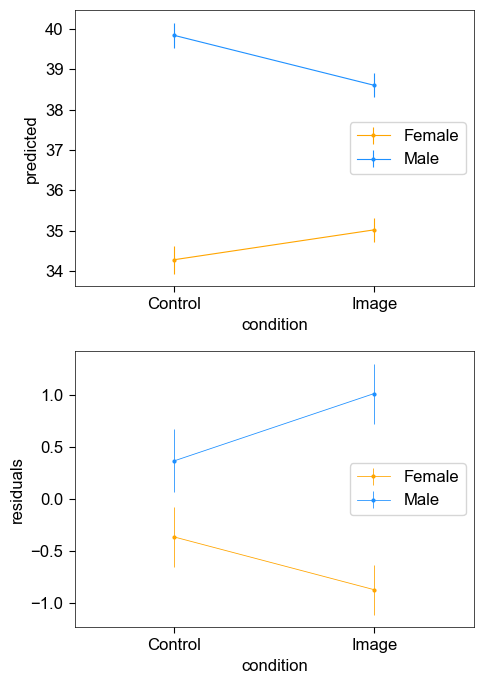

In [305]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 7))

colors = {"Female": "orange", "Male": "dodgerblue"}
conditions = ["Control", "Image"]

for gender in ["Female", "Male"]:
    pred_g  = pred_grouped[pred_grouped["gender"] == gender].set_index("condition")
    resid_g = resid_grouped[resid_grouped["gender"] == gender].set_index("condition")

    # plot 1: predicted age
    means = [pred_g.loc[c, "mean"]  for c in conditions]
    lowers = [pred_g.loc[c, "lower"] for c in conditions]
    uppers = [pred_g.loc[c, "upper"] for c in conditions]
    yerr = [[m - l for m, l in zip(means, lowers)], [u - m for m, u in zip(means, uppers)]]
    ax1.errorbar(conditions, means, yerr=yerr, label=gender,color=colors[gender], marker="o", linewidth=0.8, capsize=0, markersize = 2)

    # plot 2: residuals
    means = [resid_g.loc[c, "mean"] for c in conditions]
    lowers = [resid_g.loc[c, "lower"] for c in conditions]
    uppers = [resid_g.loc[c, "upper"] for c in conditions]
    yerr = [[m - l for m, l in zip(means, lowers)], [u - m for m, u in zip(means, uppers)]]
    ax2.errorbar(conditions, means, yerr=yerr, label=gender,color=colors[gender], marker="o", linewidth=0.58, capsize=0, markersize = 2)

ax1.set_ylabel("predicted")
ax1.set_xlabel("condition")
ax1.legend(loc="center right")
ax1.set_xlim(-0.5, 1.5)
ax1.spines[:].set_linewidth(0.5)

ax2.set_ylabel("residuals")
ax2.set_xlabel("condition")
ax2.legend(loc="center right")
ax2.set_xlim(-0.5, 1.5)
ax2.spines[:].set_linewidth(0.5)

plt.tight_layout()
plt.show()

### Interpreting the resutls
**Top plot: Predicted Age**

The baseline model, which uses only occupation and subject fixed effects with no gender or condition information, predicts that Male images are associated with ages around 39 to 40 years, while Female images are associated with ages around 34 to 35 years. This gap exists in both the control and image conditions, confirming that a baseline age-gender bias already exists in people's beliefs independently of any image exposure. People already associate occupations with younger ages when they think of women and older ages when they think of men. Notably, the predicted age for Male images decreases slightly from Control to Image, while Female increases slightly, which reflects differences in which occupations were searched in each condition rather than a true experimental effect.

**Bottom plot: Residuals**

This is the key plot for measuring amplification. The residuals represent how much the actual age estimates deviate from what the baseline model predicts based on occupation and participant alone. In the control condition, both Female and Male residuals are already slightly non-zero, with Female being negative and Male being positive, reflecting pre-existing bias in people's baseline beliefs. However, in the image condition this divergence widens substantially. Female residuals drop to around minus 0.9 and Male residuals rise to around plus 1.0. This diverging pattern is the visual signature of amplification: exposure to gendered occupational images pushes age estimates further apart than baseline beliefs alone would predict, with female images driving estimates younger and male images driving estimates older.

# ANoVA Models

We run two ANOVA models to test the effect of condition and gender on age estimates.

The first model includes only the condition by gender interaction, giving us the raw 
effect of these two variables without controlling for occupation or participant 
differences. The second model adds category and subject fixed effects, which absorbs 
variance due to differences across occupations and individual participants, giving a 
cleaner estimate of the condition by gender interaction.

Sum encoding (also called effects coding) is used for both condition and gender in 
both models. Unlike dummy coding which compares each level to a reference category, 
sum encoding compares each level to the overall grand mean. This means the 
coefficients represent deviations from the average across all groups, which is more 
appropriate for ANOVA-style interpretations where we care about main effects and 
interactions rather than pairwise comparisons to a baseline.

In [306]:
aov1 = ols(formula = "age ~ C(condition, Sum) * C(gender, Sum)", data = dt_full)
aov1_res = aov1.fit()
anova1 = anova_lm(aov1_res, typ = 2)
anova1

,sum_sq,df,F,PR(>F)
"C(condition, Sum)",57.586138,1.0,0.607880,4.356088e-01
"C(gender, Sum)",71856.913990,1.0,758.522619,5.017108e-160
"C(condition, Sum):C(gender, Sum)",347.367889,1.0,3.666820,5.553946e-02
Residual,806175.481608,8510.0,NaN,NaN


In [307]:
aov2 = ols(formula = "age ~ C(condition, Sum) * C(gender, Sum) + C(category) + C(subj)", data = dt_full)
aov2_res = aov2.fit()
anova2 = anova_lm(aov2_res, typ = 2)
anova2

,sum_sq,df,F,PR(>F)
"C(condition, Sum)",620.352248,1.0,13.649851,2.217273e-04
"C(gender, Sum)",8055.025507,1.0,177.237846,5.166031e-40
C(category),230669.638586,53.0,95.764404,0.000000e+00
C(subj),456023.489314,453.0,22.150246,0.000000e+00
"C(condition, Sum):C(gender, Sum)",329.073698,1.0,7.240736,7.141576e-03
Residual,363807.622227,8005.0,NaN,NaN


### Interpretation of the ANoVA results

**Model 1: Condition and Gender only**

In the first model, without controlling for occupation or participant differences,
gender has a very strong and highly significant effect on age estimates
(F = 758.52, p < 2.2e-160), confirming that participants estimated occupations
as substantially younger when a female image was uploaded compared to a male image.
The main effect of condition alone is not significant (F = 0.61, p = 0.44),
meaning that being in the image condition versus the control condition does not
on its own shift age estimates. The interaction between condition and gender
is marginally significant (F = 3.67, p = 0.056), suggesting a trend towards
amplification but not reaching the conventional threshold of 0.05 when occupation
and participant differences are not controlled for.

**Model 2: Condition, Gender, Category and Subject**

Once we control for occupation and participant fixed effects the picture changes
substantially. The interaction between condition and gender becomes clearly
significant (F = 7.24, p = 0.007), meaning that the gender gap in age estimates
is significantly larger in the image condition than in the control condition.
This is the key finding: Google Image search amplifies age-related gender bias
above and beyond people's pre-existing beliefs. The main effect of gender remains
highly significant (F = 177.24, p < 5.2e-40), and the main effect of condition
also becomes significant once occupation and participant variance is removed
(F = 13.65, p = 0.0002). Both category (F = 95.76, p < 0.001) and subject
(F = 22.15, p < 0.001) fixed effects explain substantial variance in age estimates,
which is why controlling for them sharpens the interaction effect.